# PyNRPF v0.1.0  Publication Figures

This notebook generates publication-ready figures from the local dataset.

Figures exported to `outputs/publication_figures/` (PNG, 300 dpi):
1. Sample RPF day time plot (ground truth MW and net load MW)
2. Deterministic threshold-rule (DTR) illustration on the same sample day
3. Test-set confusion matrices (m7 + m8, day + interval)


In [1]:
#  Environment + imports 
from pathlib import Path
from datetime import time as dt_time
import sys, random

# Make src importable
REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

from src.io import (
    load_yaml, req, get,
    verify_sha256_best_effort, load_parquet,
    ensure_dir,
)
from src.validate import basic_validate
from src.m7_threshold import run_m7
from src.m8_xgb import run_m8
from src.evaluate import plot_all_confusion_matrices

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 22,
    "axes.titlesize": 26,
    "axes.labelsize": 24,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 22,
    "figure.titlesize": 28,
    "axes.edgecolor": "0.2",
    "axes.labelcolor": "0.1",
    "text.color": "0.1",
    "xtick.color": "0.2",
    "ytick.color": "0.2",
    "axes.grid": True,
    "grid.color": "0.85",
    "grid.linewidth": 0.6,
})

print("Python:", sys.version)
print("CWD:   ", Path.cwd())
print("REPO:  ", REPO_ROOT)


Python: 3.12.3 (tags/v3.12.3:f6650f9, Apr  9 2024, 14:05:25) [MSC v.1938 64 bit (AMD64)]
CWD:    C:\Users\z5404477\Documents\PyNRPF\notebooks
REPO:   C:\Users\z5404477\Documents\PyNRPF


In [2]:
#  CONFIG 
import pickle

CFG_PATH = REPO_ROOT / "config" / "run.yaml"
cfg = load_yaml(CFG_PATH)
print("Config loaded from:", CFG_PATH)

# -- Run settings
RUN_TAG = str(req(cfg, "run.run_tag"))
SEED    = int(req(cfg, "run.seed"))
random.seed(SEED)
np.random.seed(SEED)

# -- Paths
DATASET_PATH = (REPO_ROOT / str(req(cfg, "paths.dataset_parquet"))).resolve()
SHA_PATH     = (REPO_ROOT / str(req(cfg, "paths.sha256_file"))).resolve()
OUTPUT_DIR   = (REPO_ROOT / str(req(cfg, "paths.output_dir"))).resolve()
PUB_FIG_DIR  = OUTPUT_DIR / "publication_figures"
ensure_dir(PUB_FIG_DIR)

FIG_VALUES_DIR = PUB_FIG_DIR / "values"
ensure_dir(FIG_VALUES_DIR)
FIG_VALUES_PATH = FIG_VALUES_DIR / f"figure_values__{RUN_TAG}.pkl"
FIG_VALUES_VERSION = 1
USE_FIGURE_VALUES_CACHE = bool(get(cfg, "publication_figures.use_cached_values", True))
REBUILD_FIGURE_VALUES = bool(get(cfg, "publication_figures.rebuild_cached_values", False))
FIG_VALUES = None

if USE_FIGURE_VALUES_CACHE and FIG_VALUES_PATH.exists() and not REBUILD_FIGURE_VALUES:
    try:
        with FIG_VALUES_PATH.open("rb") as f:
            loaded = pickle.load(f)
        if isinstance(loaded, dict) and loaded.get("version") == FIG_VALUES_VERSION and loaded.get("run_tag") == RUN_TAG:
            FIG_VALUES = loaded
            print(f"Loaded cached figure values: {FIG_VALUES_PATH}")
        else:
            print("Cached figure values found but version/run_tag mismatch; cache will be rebuilt.")
    except Exception as e:
        print(f"Could not load cached figure values ({e}); cache will be rebuilt.")

if FIG_VALUES is None:
    print(f"Figure values cache miss: {FIG_VALUES_PATH}")
else:
    print("Using cached figure values; dataset/model recomputation will be skipped where possible.")

# -- Column names
COL_SITE  = str(req(cfg, "data.columns.site"))
COL_TS    = str(req(cfg, "data.columns.ts"))
COL_NET   = str(req(cfg, "data.columns.net_load"))
COL_SOLAR = str(req(cfg, "data.columns.solar"))
COL_GT    = str(req(cfg, "data.columns.gt"))
ALL_COLS  = [COL_SITE, COL_TS, COL_NET, COL_SOLAR, COL_GT]

# -- Data settings
INTERVAL_MINUTES = int(req(cfg, "data.interval_minutes"))

# -- Validation flags
VERIFY_SHA256           = bool(get(cfg, "validation.verify_sha256_best_effort", True))
STRIP_TIMEZONE          = bool(get(cfg, "validation.strip_timezone", True))
ENFORCE_INTERVAL_ALIGN  = bool(get(cfg, "validation.enforce_interval_alignment", True))
ENFORCE_UNIQUE_KEYS     = bool(get(cfg, "validation.enforce_unique_keys", True))

# -- Train / test split dates
TRAIN_START = str(req(cfg, "split.train_start"))
TRAIN_END   = str(req(cfg, "split.train_end"))
TEST_START  = str(req(cfg, "split.test_start"))
TEST_END    = str(req(cfg, "split.test_end"))
split_cfg = {"train_end": TRAIN_END, "test_start": TEST_START}

print(f"RUN_TAG:  {RUN_TAG}")
print(f"SEED:     {SEED}")
print(f"DATASET:  {DATASET_PATH}")
print(f"SPLIT:    train {TRAIN_START}..{TRAIN_END} | test {TEST_START}..{TEST_END}")
print(f"FIG_DIR:  {PUB_FIG_DIR}")
print(f"FIG_VALS: {FIG_VALUES_PATH}")

Config loaded from: C:\Users\z5404477\Documents\PyNRPF\config\run.yaml
Loaded cached figure values: C:\Users\z5404477\Documents\PyNRPF\outputs\publication_figures\values\figure_values__local_dev.pkl
Using cached figure values; dataset/model recomputation will be skipped where possible.
RUN_TAG:  local_dev
SEED:     123
DATASET:  C:\Users\z5404477\Documents\PyNRPF\data\raw\rpf_dataset.parquet
SPLIT:    train 2021-11-01..2023-09-30 | test 2023-10-01..2024-09-30
FIG_DIR:  C:\Users\z5404477\Documents\PyNRPF\outputs\publication_figures
FIG_VALS: C:\Users\z5404477\Documents\PyNRPF\outputs\publication_figures\values\figure_values__local_dev.pkl


In [3]:
#  Ensure local dataset exists 
if FIG_VALUES is None:
    if not DATASET_PATH.exists():
        print("Dataset not found locally.")
        print("Please place the parquet at:", DATASET_PATH)
        raise SystemExit("Stopping: no local dataset available.")

    local_path = DATASET_PATH
    print("Parquet found locally:", local_path)
else:
    local_path = DATASET_PATH
    print("Using cached figure values: skipping dataset existence requirement.")

Using cached figure values: skipping dataset existence requirement.


In [4]:
#  Load dataset 
if FIG_VALUES is None:
    if VERIFY_SHA256:
        sha_result = verify_sha256_best_effort(local_path, SHA_PATH)
        print("SHA-256 check:", sha_result["status"],
              f"({sha_result.get('note', '')})" if sha_result.get("note") else "")

    df = load_parquet(local_path)
    print(df.dtypes)
    df.head()
else:
    df = pd.DataFrame()
    print("Using cached figure values: dataset load skipped.")

Using cached figure values: dataset load skipped.


In [5]:
#  Validation 
if FIG_VALUES is None:
    result = basic_validate(
        df,
        cols_required=ALL_COLS,
        site_col=COL_SITE,
        ts_col=COL_TS,
        key_cols=[COL_SITE, COL_TS],
        interval_minutes=INTERVAL_MINUTES,
        strip_timezone=STRIP_TIMEZONE,
        enforce_interval_alignment=ENFORCE_INTERVAL_ALIGN,
        enforce_unique_keys=ENFORCE_UNIQUE_KEYS,
    )

    df = result["df"]
    summary = result["summary"]

    print("Validation passed.")
    for k, v in summary.items():
        print(f"  {k}: {v}")
else:
    print("Validation skipped because cached figure values are in use.")

Validation skipped because cached figure values are in use.


In [6]:
#  Train / test split 
if FIG_VALUES is None:
    df["date"] = df[COL_TS].dt.date

    train_mask = (df["date"] >= pd.Timestamp(TRAIN_START).date()) & (df["date"] <= pd.Timestamp(TRAIN_END).date())
    test_mask  = (df["date"] >= pd.Timestamp(TEST_START).date())  & (df["date"] <= pd.Timestamp(TEST_END).date())

    df_train = df.loc[train_mask].copy()
    df_test  = df.loc[test_mask].copy()

    print(f"Train: {len(df_train):,} rows  ({TRAIN_START} to {TRAIN_END})")
    print(f"Test:  {len(df_test):,} rows  ({TEST_START} to {TEST_END})")
    print(f"Other: {(~train_mask & ~test_mask).sum():,} rows outside split range")
else:
    df_train = pd.DataFrame()
    df_test = pd.DataFrame()
    print("Train/test split skipped because cached figure values are in use.")

Train/test split skipped because cached figure values are in use.


In [7]:
#  Run m7 deterministic method 
if FIG_VALUES is None:
    df = run_m7(df, cfg, COL_SITE, COL_TS, COL_NET, COL_SOLAR)
    print("m7 columns added:", [c for c in ["m7_rpf_flag", "m7_rpf_day", "net_load_MW_m7"] if c in df.columns])
else:
    print("Skipping m7: using cached figure values.")

Skipping m7: using cached figure values.


In [8]:
#  Run m8 XGBoost method 
if FIG_VALUES is None:
    df = run_m8(df, cfg, COL_SITE, COL_TS, COL_NET, COL_SOLAR, COL_GT)
    print("m8 columns added:", [c for c in ["m8_rpf_day", "m8_rpf_flag", "m8_prob_day", "m8_prob_ts", "net_load_MW_m8"] if c in df.columns])
else:
    print("Skipping m8: using cached figure values.")

Skipping m8: using cached figure values.


In [9]:
#  Select representative sample TP day (test split, m7 TP) 
if FIG_VALUES is not None:
    meta = dict(FIG_VALUES.get("sample_meta", {}))
    SAMPLE_SITE = meta.get("site")
    SAMPLE_DATE = pd.Timestamp(meta.get("date")).date()
    SAMPLE_SITE_LABEL = meta.get("label", SAMPLE_SITE if str(SAMPLE_SITE).lower().startswith("substation") else f"Substation {SAMPLE_SITE}")

    sample_day = FIG_VALUES["sample_day"].copy()
    sample_day[COL_TS] = pd.to_datetime(sample_day[COL_TS], errors="coerce")
    sample_day = sample_day.sort_values(COL_TS)

    print("Loaded representative sample day from cache:")
    print(f"  site: {SAMPLE_SITE}")
    print(f"  date: {SAMPLE_DATE}")
    print(f"  label: {SAMPLE_SITE_LABEL}")
else:
    df["date"] = df[COL_TS].dt.date
    test_mask = (df["date"] >= pd.Timestamp(TEST_START).date()) & (df["date"] <= pd.Timestamp(TEST_END).date())
    df_test = df.loc[test_mask].copy()

    hour = df_test[COL_TS].dt.hour
    daytime = df_test.loc[(hour >= 6) & (hour < 18)].copy()

    day_summary = (
        df_test.groupby([COL_SITE, "date"]).agg(
            true_day=(COL_GT, lambda s: bool((s < 0).any())),
            pred_day=("m7_rpf_day", "first"),
            solar_max=(COL_SOLAR, "max"),
        ).reset_index()
    )
    day_summary["tp_day"] = day_summary["true_day"] & day_summary["pred_day"].fillna(False).astype(bool)

    rpf_counts = (
        daytime.groupby([COL_SITE, "date"])[COL_GT]
        .apply(lambda s: int((s < 0).sum()))
        .reset_index(name="rpf_interval_count")
    )
    day_summary = day_summary.merge(rpf_counts, on=[COL_SITE, "date"], how="left")
    day_summary["rpf_interval_count"] = day_summary["rpf_interval_count"].fillna(0).astype(int)

    tp_days = day_summary.loc[day_summary["tp_day"]].copy()
    if tp_days.empty:
        raise RuntimeError("No TP days found in test split for m7; cannot select representative sample day.")

    target = float(tp_days["rpf_interval_count"].median())
    tp_days["score"] = (tp_days["rpf_interval_count"] - target).abs()
    tp_days = tp_days.sort_values(["score", "solar_max", "date", COL_SITE], ascending=[True, False, True, True])

    sample_row = tp_days.iloc[0]
    SAMPLE_SITE = sample_row[COL_SITE]
    SAMPLE_DATE = sample_row["date"]
    sample_day = df_test.loc[(df_test[COL_SITE] == SAMPLE_SITE) & (df_test["date"] == SAMPLE_DATE)].copy()
    sample_day = sample_day.sort_values(COL_TS)

    print("Selected representative sample day:")
    print(f"  site: {SAMPLE_SITE}")
    print(f"  date: {SAMPLE_DATE}")
    print(f"  daytime GT-RPF intervals: {int(sample_row['rpf_interval_count'])}")
    print(f"  target (median): {target:.1f}")


    SAMPLE_SITE_LABEL = SAMPLE_SITE if str(SAMPLE_SITE).lower().startswith("substation") else f"Substation {SAMPLE_SITE}"
    print(f"  label: {SAMPLE_SITE_LABEL}")

Loaded representative sample day from cache:
  site: F
  date: 2024-02-17
  label: Substation F


Saved: C:\Users\z5404477\Documents\PyNRPF\outputs\publication_figures\fig01_sample_day_mw_vs_ground_truth.png


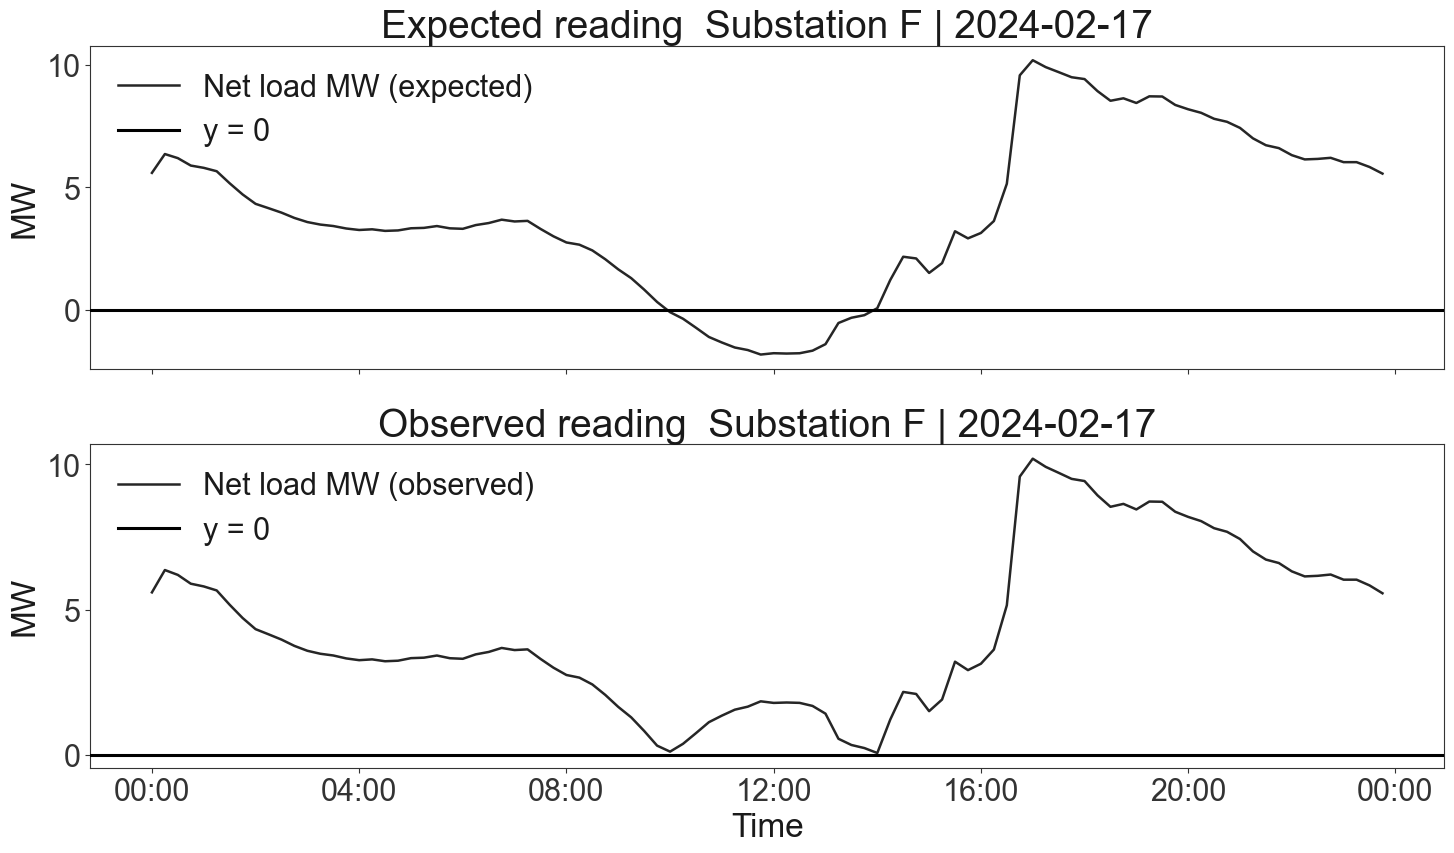

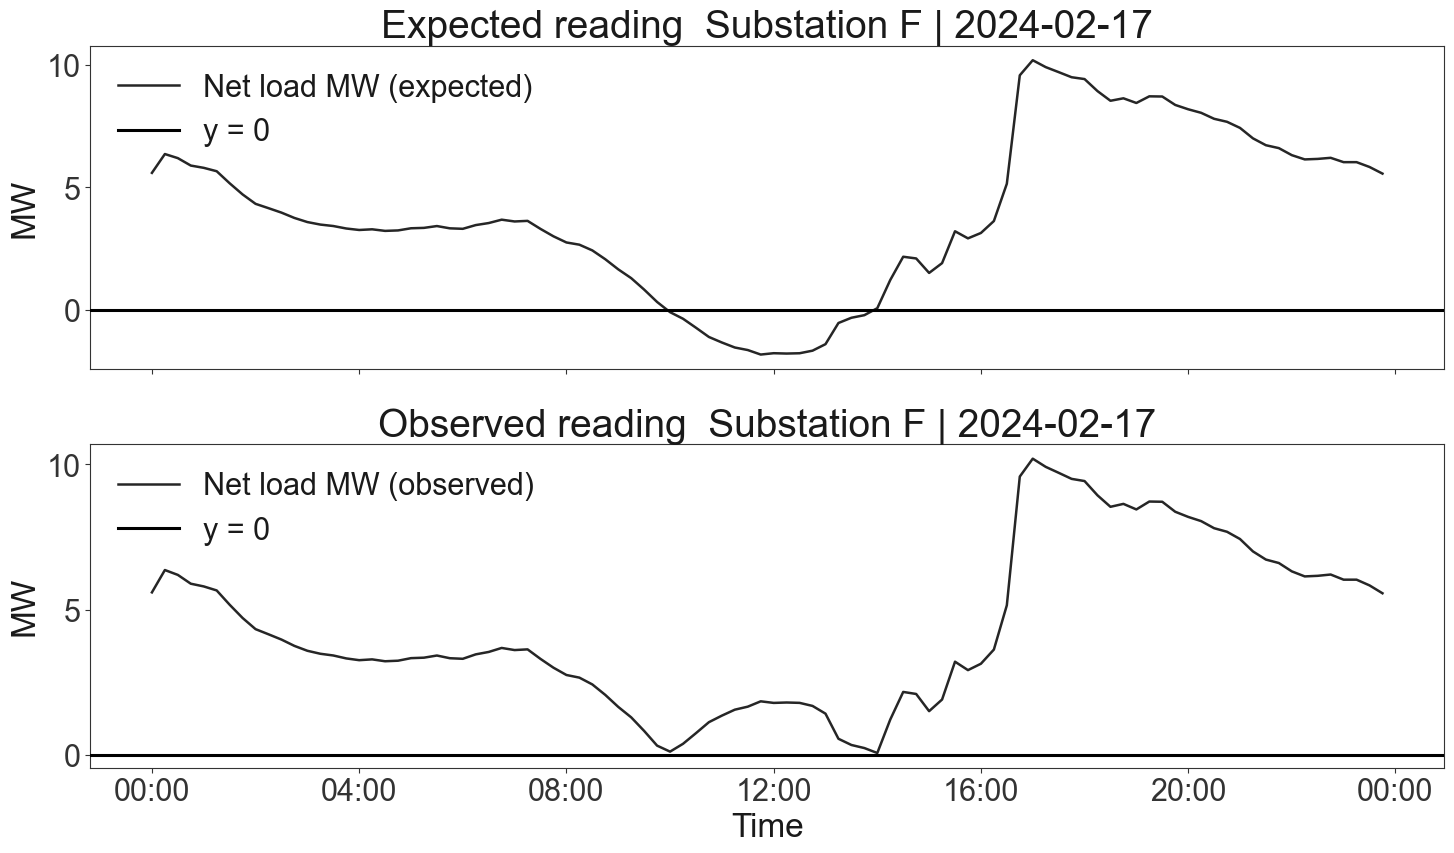

In [10]:
#  Figure 1: Sample day time plot (ground truth vs net load) 
fig1_path = PUB_FIG_DIR / "fig01_sample_day_mw_vs_ground_truth.png"

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
x = sample_day[COL_TS]
curve_color = "0.15"

for ax in axes:
    ax.set_axisbelow(True)
    ax.grid(False)

axes[0].plot(x, sample_day[COL_GT], color=curve_color, linewidth=1.8, label="Net load MW (expected)")
axes[0].axhline(0, color="0.0", linewidth=2.2, linestyle="-", zorder=5, label="y = 0")
axes[0].set_ylabel("MW", fontsize=24)
axes[0].set_title(f"Expected reading  {SAMPLE_SITE_LABEL} | {SAMPLE_DATE}", fontsize=28)
axes[0].legend(loc="upper left", frameon=False, fontsize=22)

axes[1].plot(x, sample_day[COL_NET], color=curve_color, linewidth=1.8, label="Net load MW (observed)")
axes[1].axhline(0, color="0.0", linewidth=2.2, linestyle="-", zorder=5, label="y = 0")
axes[1].set_ylabel("MW", fontsize=24)
axes[1].set_xlabel("Time", fontsize=24)
axes[1].set_title(f"Observed reading  {SAMPLE_SITE_LABEL} | {SAMPLE_DATE}", fontsize=28)
axes[1].legend(loc="upper left", frameon=False, fontsize=22)

axes[1].xaxis.set_major_locator(mdates.HourLocator(interval=4))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
for ax in axes:
    ax.yaxis.set_major_locator(mticker.MultipleLocator(5))
    ax.tick_params(axis="both", labelsize=22)
fig.tight_layout()
fig.savefig(fig1_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig1_path}")
fig


Loaded DTR diagnostic values from cache.


Saved: C:\Users\z5404477\Documents\PyNRPF\outputs\publication_figures\fig02_dtr_illustration.png


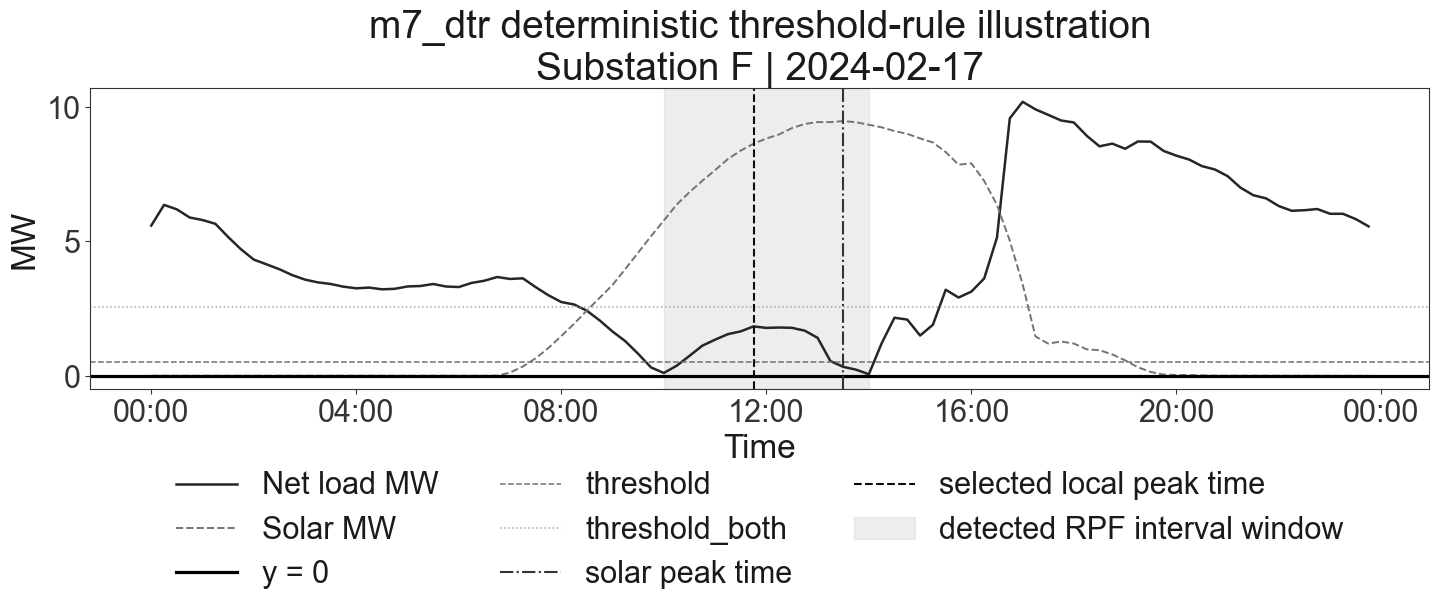

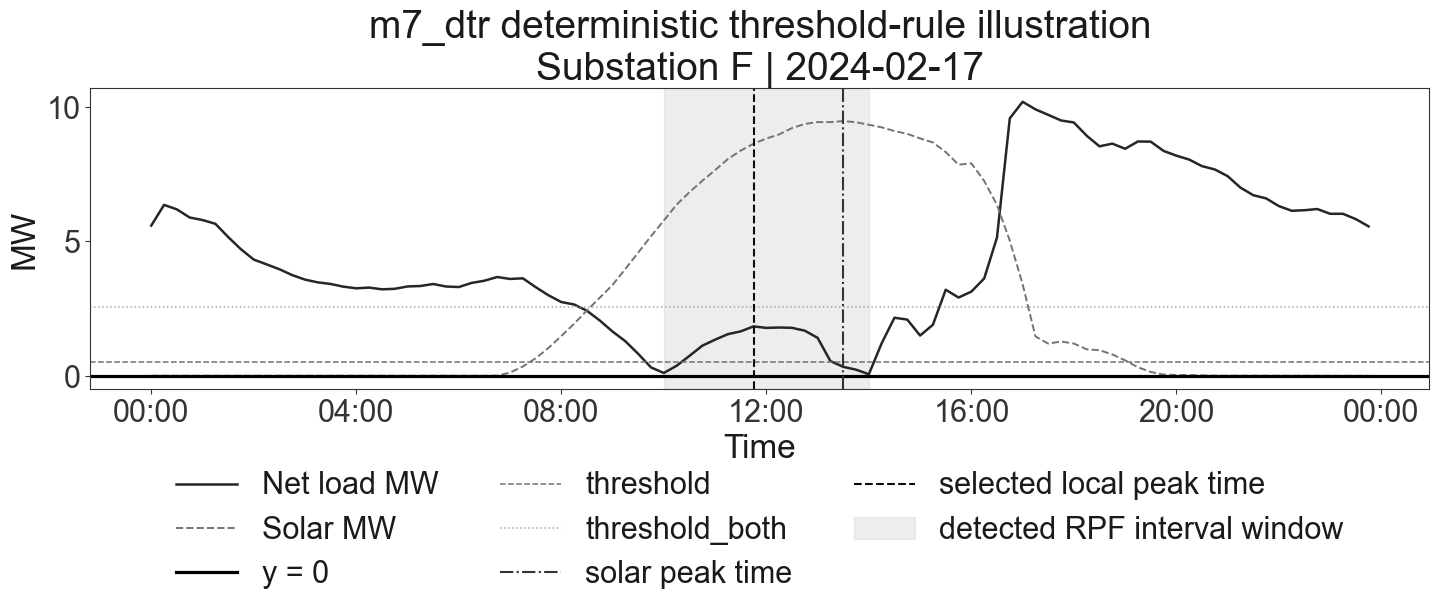

In [11]:
#  Figure 2: m7_dtr deterministic threshold-rule illustration 
def _parse_time(s: str) -> dt_time:
    p = s.strip().split(":")
    return dt_time(int(p[0]), int(p[1]), int(p[2]) if len(p) > 2 else 0)

def extract_m7_single_day_diag(day_df: pd.DataFrame, cfg: dict) -> dict:
    m7 = req(cfg, "m7_threshold")
    tiebreak_time = _parse_time(str(m7["solar_peak_tiebreak_time"]))
    window_minutes = int(m7["peak_window_minutes"])
    min_threshold = float(req(m7, "min_threshold"))
    min_threshold_both = float(req(m7, "min_threshold_both"))

    d = day_df.sort_values(COL_TS).copy()
    ts = d[COL_TS].values.astype("datetime64[ns]").astype(np.int64)
    mw = d[COL_NET].values.astype(float)
    solar = d[COL_SOLAR].values.astype(float)

    if np.any(np.isnan(mw)):
        raise RuntimeError("Sample day has missing MW; DTR diagnostic not available.")
    if np.any(mw < 0):
        raise RuntimeError("Sample day has already-negative MW; DTR day gate fails.")

    day0 = pd.Timestamp(d[COL_TS].iloc[0]).normalize()
    midnight = int(day0.to_datetime64().astype("datetime64[ns]").astype(np.int64))

    secs = (ts - midnight) / 1_000_000_000
    midday = (secs >= 21600) & (secs < 64800)
    if midday.sum() < 3:
        raise RuntimeError("Sample day has <3 midday points; DTR day gate fails.")

    max_mw = float(np.nanmax(mw))
    th = max_mw * min_threshold
    th_both = max_mw * min_threshold_both

    mi = np.where(midday)[0]
    ts_m, mw_m, sol_m = ts[mi], mw[mi], solar[mi]

    tb_offset = tiebreak_time.hour * 3_600_000_000_000 + tiebreak_time.minute * 60_000_000_000
    tb_i64 = midnight + tb_offset
    win_ns = int(window_minutes * 60 * 1_000_000_000)

    sol_ok = ~np.isnan(sol_m)
    if sol_ok.any():
        si = np.where(sol_ok)[0]
        dist = np.abs(ts_m[si] - tb_i64)
        order = np.lexsort((ts_m[si], dist, -sol_m[si]))
        solar_ts = int(ts_m[si][order[0]])
        wl, wh = solar_ts - win_ns, solar_ts + win_ns
    else:
        solar_ts = int(midnight + 12 * 3_600_000_000_000)
        wl = int(midnight + 10 * 3_600_000_000_000)
        wh = int(midnight + 15 * 3_600_000_000_000 - 1)

    lmax = np.zeros(len(mw_m), dtype=bool)
    if len(mw_m) >= 3:
        lmax[1:-1] = (mw_m[1:-1] > mw_m[:-2]) & (mw_m[1:-1] > mw_m[2:])

    cand = np.where((ts_m >= wl) & (ts_m <= wh) & lmax)[0]
    if len(cand) == 0:
        raise RuntimeError("No DTR candidates in solar window for sample day.")

    best = None
    for c in cand:
        peak_ts = int(ts_m[c])
        peak_mw = float(mw_m[c])

        lm_mask = (ts < peak_ts) & (mw < th_both)
        rm_mask = (ts > peak_ts) & (mw < th_both)
        if not lm_mask.any() or not rm_mask.any():
            continue

        li = np.where(lm_mask)[0]
        ri = np.where(rm_mask)[0]
        l_idx = li[int(np.argmin(mw[li]))]
        r_idx = ri[int(np.argmin(mw[ri]))]

        l_mw, l_ts = float(mw[l_idx]), int(ts[l_idx])
        r_mw, r_ts = float(mw[r_idx]), int(ts[r_idx])
        s = l_mw + r_mw
        rank = (s, -peak_mw)
        payload = {
            "peak_ts": peak_ts, "peak_mw": peak_mw,
            "left_ts": l_ts, "left_mw": l_mw,
            "right_ts": r_ts, "right_mw": r_mw,
            "rank": rank,
        }
        if best is None or rank < best["rank"]:
            best = payload

    if best is None:
        raise RuntimeError("No valid left/right minima pair found for DTR diagnostic.")
    if not (best["left_mw"] < th or best["right_mw"] < th):
        raise RuntimeError("Threshold gate failed on sample day for DTR diagnostic.")

    return {
        "threshold": th,
        "threshold_both": th_both,
        "solar_peak_ts": pd.to_datetime(solar_ts, unit="ns"),
        "selected_peak_ts": pd.to_datetime(best["peak_ts"], unit="ns"),
        "left_min_ts": pd.to_datetime(best["left_ts"], unit="ns"),
        "right_min_ts": pd.to_datetime(best["right_ts"], unit="ns"),
    }

if FIG_VALUES is not None and "diag" in FIG_VALUES:
    diag = FIG_VALUES["diag"]
    print("Loaded DTR diagnostic values from cache.")
else:
    diag = extract_m7_single_day_diag(sample_day, cfg)
fig2_path = PUB_FIG_DIR / "fig02_dtr_illustration.png"

fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(sample_day[COL_TS], sample_day[COL_NET], color="0.15", linewidth=1.8, label="Net load MW")
ax.plot(sample_day[COL_TS], sample_day[COL_SOLAR], color="0.45", linewidth=1.4, linestyle="--", label="Solar MW")
ax.axhline(0, color="0.0", linestyle="-", linewidth=2.3, label="y = 0")
ax.axhline(diag["threshold"], color="0.45", linestyle="--", linewidth=1.1, label="threshold")
ax.axhline(diag["threshold_both"], color="0.65", linestyle=":", linewidth=1.1, label="threshold_both")
ax.axvline(diag["solar_peak_ts"], color="0.2", linestyle="-.", linewidth=1.5, label="solar peak time")
ax.axvline(diag["selected_peak_ts"], color="0.05", linestyle="--", linewidth=1.5, label="selected local peak time")
ax.axvspan(diag["left_min_ts"], diag["right_min_ts"], color="0.8", alpha=0.35, label="detected RPF interval window")

ax.set_title(f"m7_dtr deterministic threshold-rule illustration\n{SAMPLE_SITE_LABEL} | {SAMPLE_DATE}", fontsize=28)
ax.set_xlabel("Time", fontsize=24)
ax.set_ylabel("MW", fontsize=24)
ax.grid(False)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.yaxis.set_major_locator(mticker.MultipleLocator(5))
ax.tick_params(axis="both", labelsize=22)
h1, l1 = ax.get_legend_handles_labels()

ax.legend(h1, l1, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False, fontsize=22)
fig.tight_layout()
fig.savefig(fig2_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig2_path}")
fig

Loaded cached confusion values.


Saved: C:\Users\z5404477\Documents\PyNRPF\outputs\publication_figures\confusion_matrices_all_daytime.png


Saved: C:\Users\z5404477\Documents\PyNRPF\outputs\publication_figures\confusion_matrices_tp_days_only_interval.png


Saved: C:\Users\z5404477\Documents\PyNRPF\outputs\publication_figures\fig03_confusion_matrices_1x4.png

Publication figures generated:
  - C:\Users\z5404477\Documents\PyNRPF\outputs\publication_figures\fig01_sample_day_mw_vs_ground_truth.png
  - C:\Users\z5404477\Documents\PyNRPF\outputs\publication_figures\fig02_dtr_illustration.png
  - C:\Users\z5404477\Documents\PyNRPF\outputs\publication_figures\confusion_matrices_all_daytime.png
  - C:\Users\z5404477\Documents\PyNRPF\outputs\publication_figures\confusion_matrices_tp_days_only_interval.png
  - C:\Users\z5404477\Documents\PyNRPF\outputs\publication_figures\fig03_confusion_matrices_1x4.png


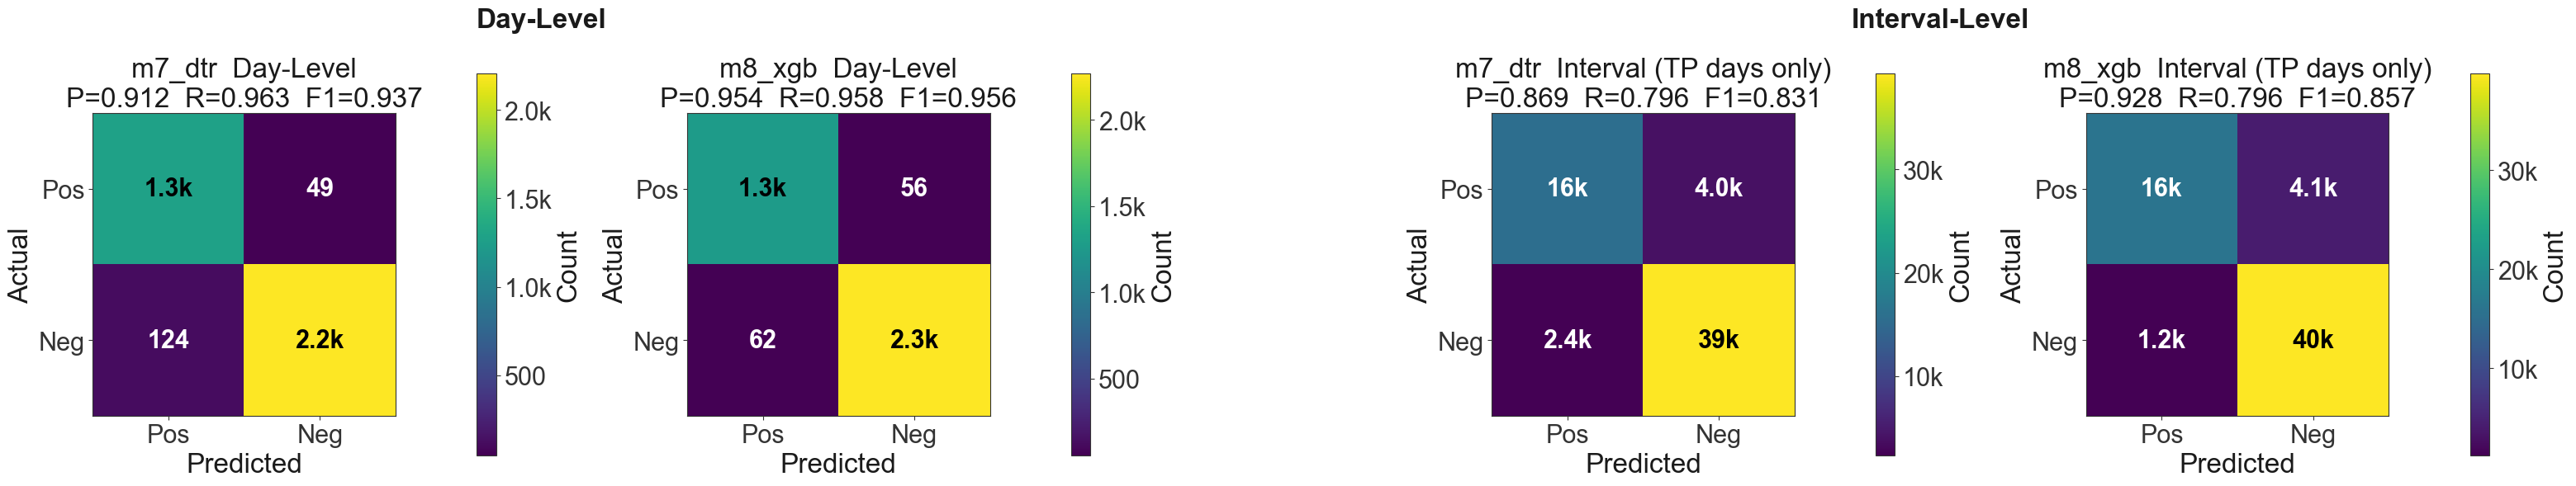

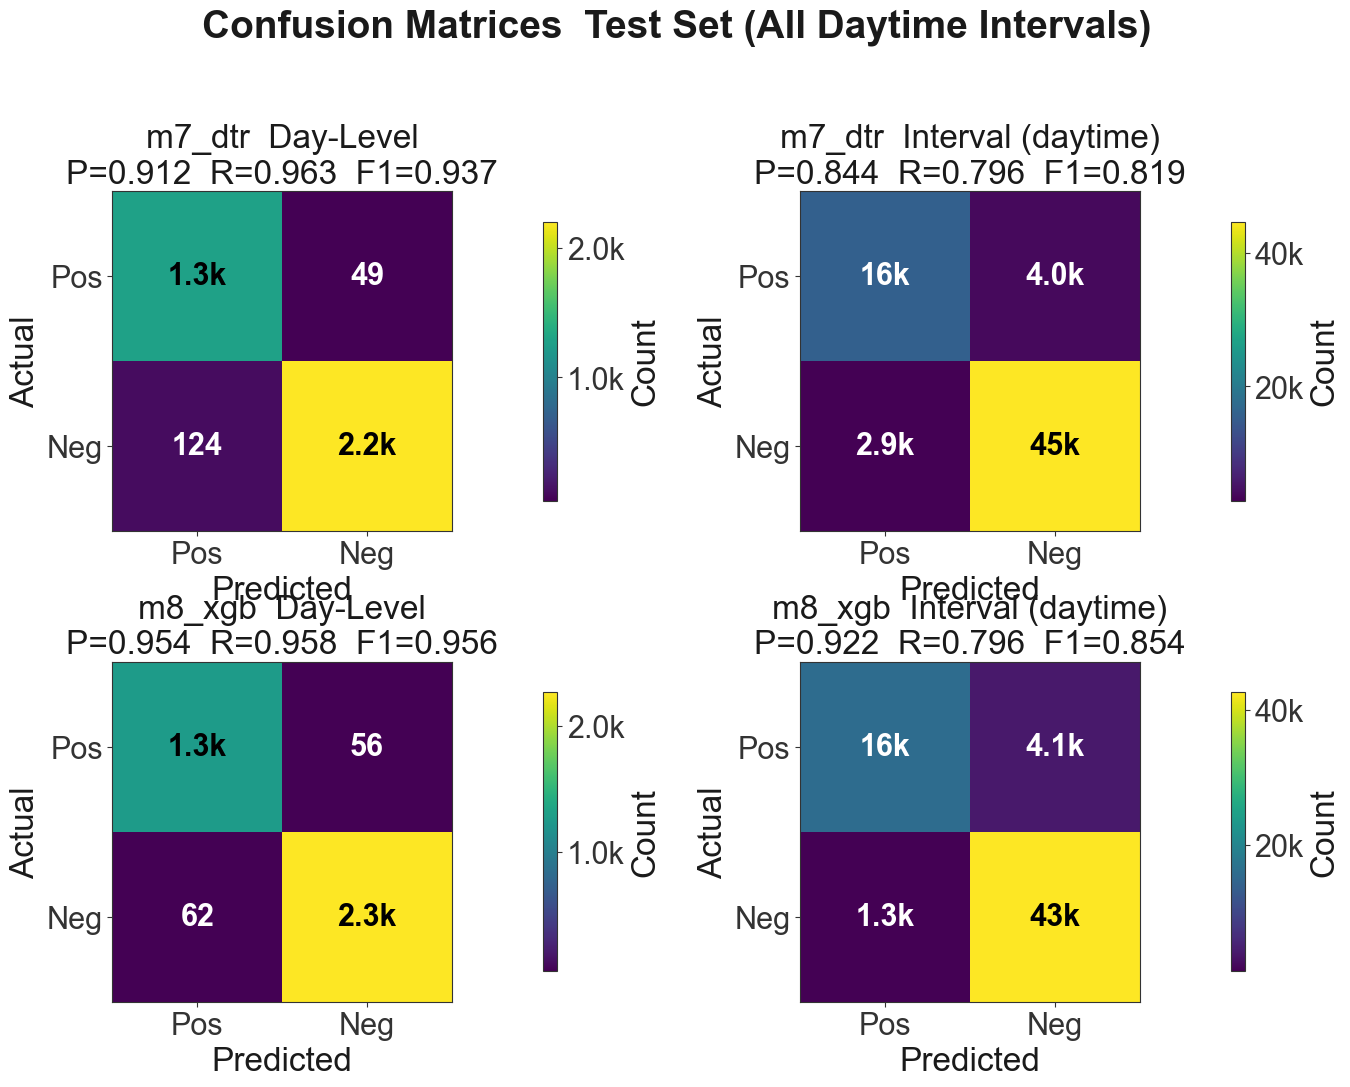

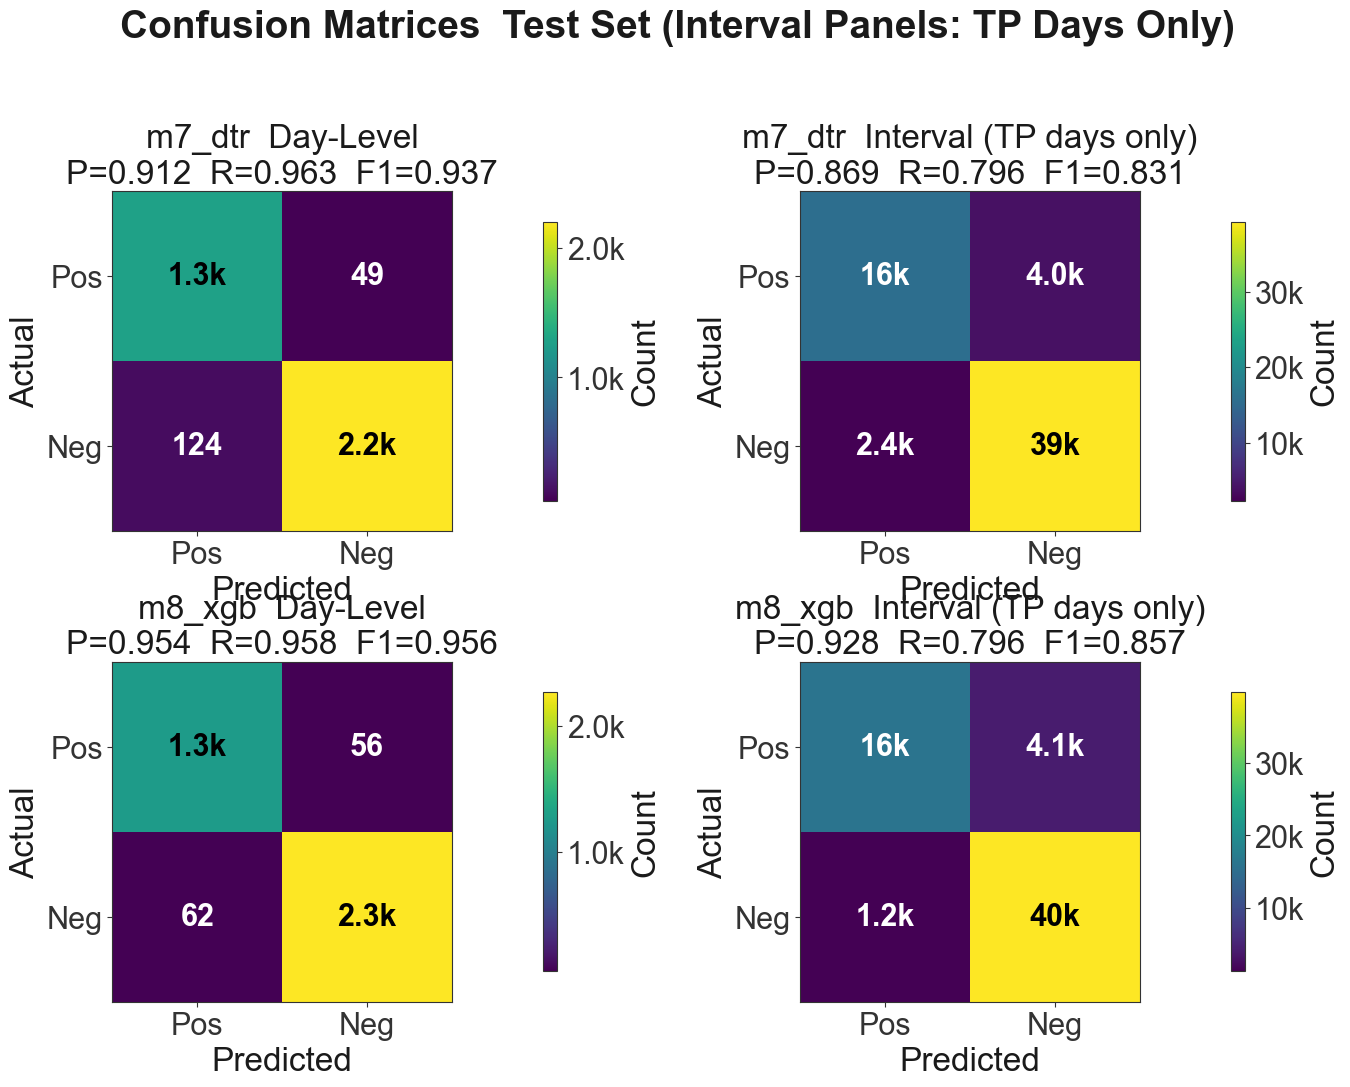

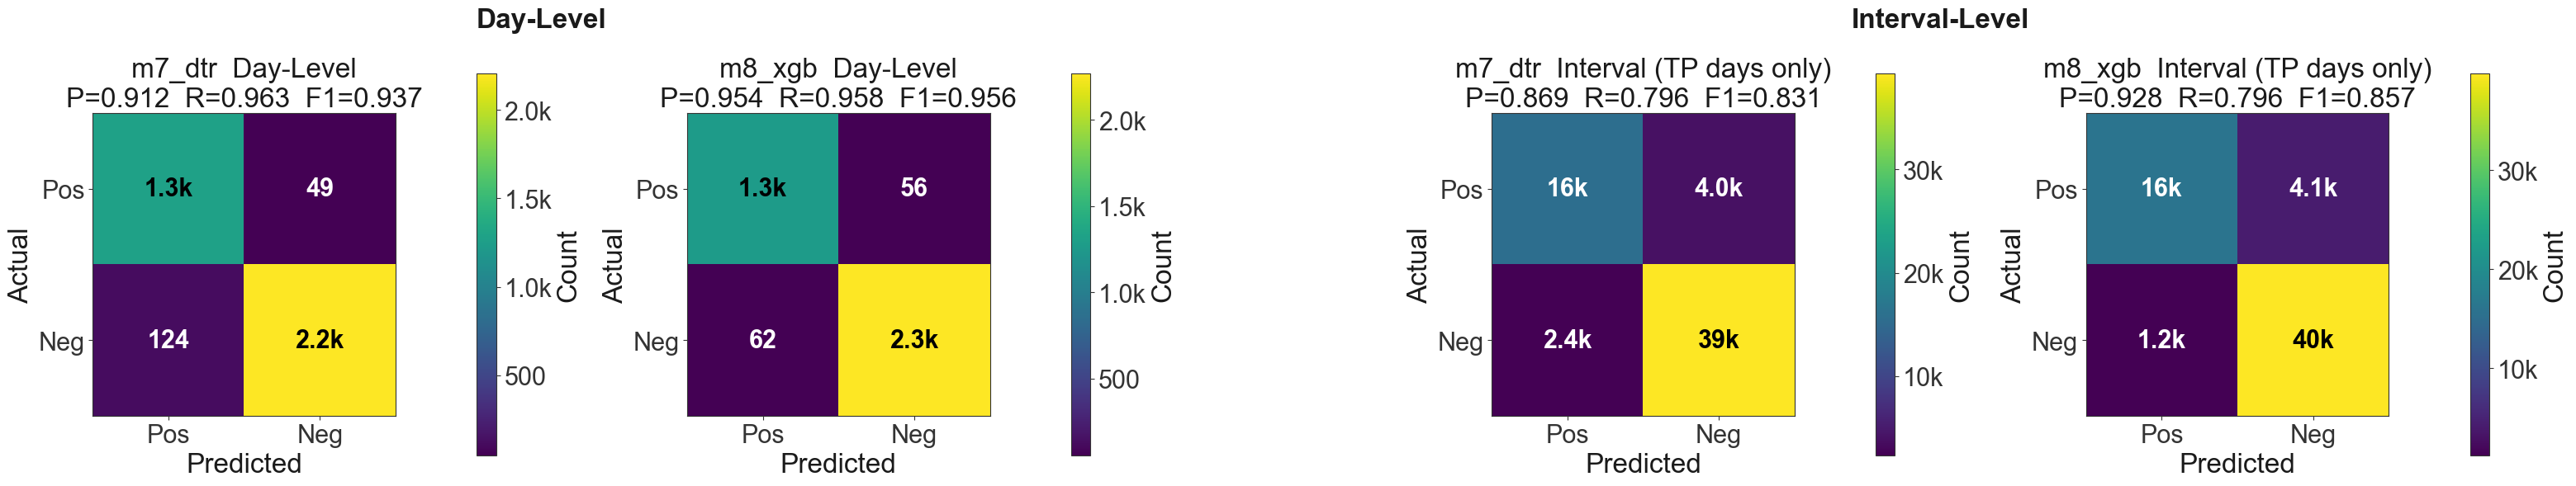

In [12]:
#  Confusion matrices: legacy and new Figure 3 layout 
import matplotlib.ticker as mtick
from src.evaluate import compute_metrics

def _format_k(value: float) -> str:
    if abs(value) >= 1000:
        k = value / 1000.0
        return f"{k:.1f}k" if abs(k) < 10 else f"{k:.0f}k"
    return f"{int(round(value))}"

def _to_bool_array(x):
    return np.asarray(x, dtype=bool)

def _plot_cm_with_cbar(ax, fig, y_true, y_pred, title):
    y_t = _to_bool_array(y_true)
    y_p = _to_bool_array(y_pred)
    tp = int((y_p & y_t).sum())
    fp = int((y_p & ~y_t).sum())
    fn = int((~y_p & y_t).sum())
    tn = int((~y_p & ~y_t).sum())
    cm = np.array([[tp, fn], [fp, tn]], dtype=float)

    m = compute_metrics(y_t, y_p, rounding=3)
    im = ax.imshow(cm, interpolation='nearest', cmap='viridis')
    cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.18)
    cbar.set_label('Count', fontsize=24)
    cbar.ax.tick_params(labelsize=22)
    cbar.formatter = mtick.FuncFormatter(lambda x, pos: _format_k(x))
    cbar.update_ticks()

    for i in range(2):
        for j in range(2):
            val = int(cm[i, j])
            colour = 'white' if val < cm.max() * 0.5 else 'black'
            ax.text(j, i, _format_k(val), ha='center', va='center', fontsize=22, fontweight='bold', color=colour)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pos', 'Neg'], fontsize=22)
    ax.set_yticklabels(['Pos', 'Neg'], fontsize=22)
    ax.set_xlabel('Predicted', fontsize=24)
    ax.set_ylabel('Actual', fontsize=24)
    ax.set_title(f"{title}\nP={m['precision']:.3f}  R={m['recall']:.3f}  F1={m['f1']:.3f}", fontsize=24)
    ax.grid(False)

def _build_confusion_sets(df, day_col, flag_col, interval_tp_only=False):
    dates = pd.to_datetime(df['date'])
    test = df.loc[(dates >= pd.Timestamp(TEST_START)) & (dates <= pd.Timestamp(TEST_END))].copy()

    # Exclude already-negative input days (match existing evaluator behavior)
    neg_day_keys = (
        test.groupby([COL_SITE, 'date'])[COL_NET]
        .min()
        .reset_index(name='_nm')
    )
    keep_keys = neg_day_keys.loc[neg_day_keys['_nm'] >= 0, [COL_SITE, 'date']]
    test = test.merge(keep_keys, on=[COL_SITE, 'date'], how='inner')

    day_agg = test.groupby([COL_SITE, 'date']).agg(gt_min=(COL_GT, 'min')).reset_index()
    day_agg['y_true'] = day_agg['gt_min'] < 0
    day_pred = test.groupby([COL_SITE, 'date'])[day_col].first().reset_index(name='y_pred')
    day_eval = day_agg.merge(day_pred, on=[COL_SITE, 'date'], how='inner')

    hour = test[COL_TS].dt.hour
    interval = test.loc[(hour >= 6) & (hour < 18)].dropna(subset=[COL_GT]).copy()

    if interval_tp_only:
        day_tp = day_eval.loc[day_eval['y_true'] & day_eval['y_pred'], [COL_SITE, 'date']]
        interval = interval.merge(day_tp, on=[COL_SITE, 'date'], how='inner')

    y_true_int = (interval[COL_GT] < 0).values
    y_pred_int = interval[flag_col].values.astype(bool)

    return day_eval['y_true'].values, day_eval['y_pred'].values.astype(bool), y_true_int, y_pred_int

def _compute_confusion_values(df):
    methods = [
        ('m7_rpf_day', 'm7_rpf_flag', 'm7_dtr'),
        ('m8_rpf_day', 'm8_rpf_flag', 'm8_xgb'),
    ]

    values = {}
    for dcol, fcol, label in methods:
        ytd, ypd, yti_all, ypi_all = _build_confusion_sets(df, dcol, fcol, interval_tp_only=False)
        _, _, yti_tp, ypi_tp = _build_confusion_sets(df, dcol, fcol, interval_tp_only=True)
        values[label] = {
            'day': {'y_true': _to_bool_array(ytd), 'y_pred': _to_bool_array(ypd)},
            'interval_daytime': {'y_true': _to_bool_array(yti_all), 'y_pred': _to_bool_array(ypi_all)},
            'interval_tp_days_only': {'y_true': _to_bool_array(yti_tp), 'y_pred': _to_bool_array(ypi_tp)},
        }
    return values

def _normalize_confusion_values(values):
    out = {}
    for label, payload in values.items():
        out[label] = {
            'day': {
                'y_true': _to_bool_array(payload['day']['y_true']),
                'y_pred': _to_bool_array(payload['day']['y_pred']),
            },
            'interval_daytime': {
                'y_true': _to_bool_array(payload['interval_daytime']['y_true']),
                'y_pred': _to_bool_array(payload['interval_daytime']['y_pred']),
            },
            'interval_tp_days_only': {
                'y_true': _to_bool_array(payload['interval_tp_days_only']['y_true']),
                'y_pred': _to_bool_array(payload['interval_tp_days_only']['y_pred']),
            },
        }
    return out

if FIG_VALUES is not None and 'confusion_values' in FIG_VALUES:
    CM_VALUES = _normalize_confusion_values(FIG_VALUES['confusion_values'])
    print('Loaded cached confusion values.')
else:
    CM_VALUES = _compute_confusion_values(df)
    print('Computed confusion values from model outputs.')

def _plot_confusion_publication(cm_values, interval_tp_only=False, suptitle='Confusion Matrices  Test Set'):
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    fig.suptitle(suptitle, fontsize=28, fontweight='bold', y=0.98)

    labels = ['m7_dtr', 'm8_xgb']
    for r, label in enumerate(labels):
        day_vals = cm_values[label]['day']
        _plot_cm_with_cbar(axes[r, 0], fig, day_vals['y_true'], day_vals['y_pred'], f'{label}  Day-Level')

        key = 'interval_tp_days_only' if interval_tp_only else 'interval_daytime'
        suffix = 'Interval (TP days only)' if interval_tp_only else 'Interval (daytime)'
        int_vals = cm_values[label][key]
        _plot_cm_with_cbar(axes[r, 1], fig, int_vals['y_true'], int_vals['y_pred'], f'{label}  {suffix}')

    for ax in axes.ravel():
        ax.grid(False)

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

def _plot_confusion_publication_1x4(cm_values, interval_tp_only=True):
    fig = plt.figure(figsize=(31, 8.5))
    gs = fig.add_gridspec(1, 5, width_ratios=[1.0, 1.0, 0.15, 1.0, 1.0], wspace=0.38)
    axes = [
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[0, 3]),
        fig.add_subplot(gs[0, 4]),
    ]

    labels = ['m7_dtr', 'm8_xgb']
    for idx, label in enumerate(labels):
        day_vals = cm_values[label]['day']
        _plot_cm_with_cbar(axes[idx], fig, day_vals['y_true'], day_vals['y_pred'], f'{label}  Day-Level')

        key = 'interval_tp_days_only' if interval_tp_only else 'interval_daytime'
        suffix = 'Interval (TP days only)' if interval_tp_only else 'Interval (daytime)'
        int_vals = cm_values[label][key]
        _plot_cm_with_cbar(axes[idx + 2], fig, int_vals['y_true'], int_vals['y_pred'], f'{label}  {suffix}')

    fig.subplots_adjust(left=0.03, right=0.985, bottom=0.12, top=0.80)
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    # Clear visual separator between day-level (left) and interval-level (right) panels.
    b2 = axes[1].get_position()
    b3 = axes[2].get_position()
    x_mid = (b2.x1 + b3.x0) / 2.0
    y1 = max(ax.get_position().y1 for ax in axes)
    y_pred_bottom = min(
        ax.xaxis.label.get_window_extent(renderer=renderer).transformed(fig.transFigure.inverted()).y0
        for ax in axes
    )
    y_line_bottom = max(0.02, y_pred_bottom)

    subtitle_y = y1 + 0.030
    fig.text((axes[0].get_position().x0 + axes[1].get_position().x1) / 2.0, subtitle_y,
             'Day-Level\n\n', ha='center', va='bottom', fontsize=24, fontweight='bold')
    fig.text((axes[2].get_position().x0 + axes[3].get_position().x1) / 2.0, subtitle_y,
             'Interval-Level\n\n', ha='center', va='bottom', fontsize=24, fontweight='bold')

    return fig

fig_legacy_all_daytime_path = PUB_FIG_DIR / 'confusion_matrices_all_daytime.png'
fig_legacy_tp_only_path = PUB_FIG_DIR / 'confusion_matrices_tp_days_only_interval.png'
fig3_path = PUB_FIG_DIR / 'fig03_confusion_matrices_1x4.png'

fig_legacy_all = _plot_confusion_publication(
    CM_VALUES,
    interval_tp_only=False,
    suptitle='Confusion Matrices  Test Set (All Daytime Intervals)',
)
fig_legacy_all.savefig(fig_legacy_all_daytime_path, dpi=300, bbox_inches='tight')
print(f'Saved: {fig_legacy_all_daytime_path}')

fig_legacy_tp = _plot_confusion_publication(
    CM_VALUES,
    interval_tp_only=True,
    suptitle='Confusion Matrices  Test Set (Interval Panels: TP Days Only)',
)
fig_legacy_tp.savefig(fig_legacy_tp_only_path, dpi=300, bbox_inches='tight')
print(f'Saved: {fig_legacy_tp_only_path}')

fig3 = _plot_confusion_publication_1x4(
    CM_VALUES,
    interval_tp_only=True,
)
fig3.savefig(fig3_path, dpi=300, bbox_inches='tight')
print(f'Saved: {fig3_path}')

if FIG_VALUES is None:
    cache_payload = {
        'version': FIG_VALUES_VERSION,
        'run_tag': RUN_TAG,
        'sample_meta': {
            'site': SAMPLE_SITE,
            'date': str(SAMPLE_DATE),
            'label': SAMPLE_SITE_LABEL,
        },
        'sample_day': sample_day[[COL_TS, COL_NET, COL_SOLAR, COL_GT]].copy(),
        'diag': diag,
        'confusion_values': CM_VALUES,
        'created_utc': pd.Timestamp.now('UTC').isoformat(),
    }
    with FIG_VALUES_PATH.open('wb') as f:
        pickle.dump(cache_payload, f)
    print(f'Saved figure-value cache: {FIG_VALUES_PATH}')

print('\nPublication figures generated:')
for p in [fig1_path, fig2_path, fig_legacy_all_daytime_path, fig_legacy_tp_only_path, fig3_path]:
    print(f'  - {p}')

fig3
